In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn import tree

In [2]:
# Load the iris data
iris = datasets.load_iris()
#X = iris.data
X = iris.data[:, 2:]
y = iris.target

In [3]:
# Split the data into train and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [4]:
# Train and fit the model
d_tree_model = tree.DecisionTreeClassifier(max_depth=5).fit(X_train, y_train)

# Evaluate the model's accuracy
print("Train set accuracy = " + str(d_tree_model.score(X_train, y_train)))
print("Test set accuracy = " + str(d_tree_model.score(X_test, y_test)))

Train set accuracy = 0.9821428571428571
Test set accuracy = 1.0


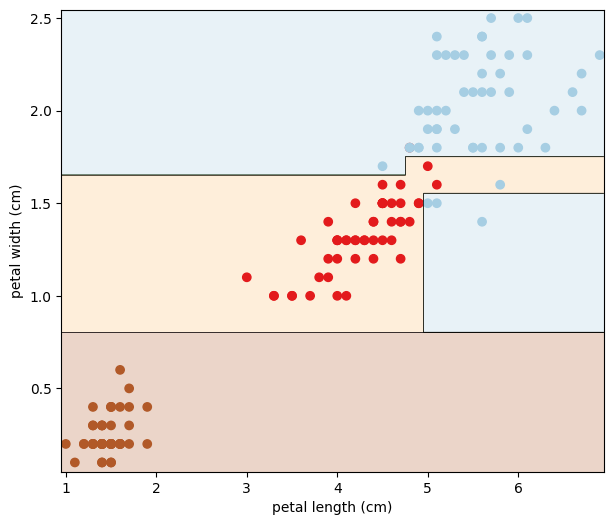

In [5]:
# Plot the decision boundaries
def plot_decision_boundary(clf, X, y, cmap='Paired_r'):
    h = 0.005  # Boundary lines' resolution
    x_min, x_max = X[:,0].min() - 10*h, X[:,0].max() + 10*h
    y_min, y_max = X[:,1].min() - 10*h, X[:,1].max() + 10*h
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(7,6))
    plt.contourf(xx, yy, Z, cmap=cmap, alpha=0.25)  # Background
    plt.contour(xx, yy, Z, colors='k', linewidths=0.2)  # Boundary lines
    plt.scatter(X[:,0], X[:,1], c=y, cmap=cmap);  # Data points
    plt.xlabel(iris.feature_names[2])
    plt.ylabel(iris.feature_names[3])

plot_decision_boundary(d_tree_model, X, y)

[Text(0.3181818181818182, 0.9166666666666666, 'x[1] <= 0.8\ngini = 0.666\nsamples = 112\nvalue = [35, 39, 38]'),
 Text(0.22727272727272727, 0.75, 'gini = 0.0\nsamples = 35\nvalue = [35, 0, 0]'),
 Text(0.2727272727272727, 0.8333333333333333, 'True  '),
 Text(0.4090909090909091, 0.75, 'x[0] <= 4.75\ngini = 0.5\nsamples = 77\nvalue = [0.0, 39.0, 38.0]'),
 Text(0.36363636363636365, 0.8333333333333333, '  False'),
 Text(0.18181818181818182, 0.5833333333333334, 'x[1] <= 1.65\ngini = 0.056\nsamples = 35\nvalue = [0, 34, 1]'),
 Text(0.09090909090909091, 0.4166666666666667, 'gini = 0.0\nsamples = 34\nvalue = [0, 34, 0]'),
 Text(0.2727272727272727, 0.4166666666666667, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1]'),
 Text(0.6363636363636364, 0.5833333333333334, 'x[1] <= 1.75\ngini = 0.21\nsamples = 42\nvalue = [0, 5, 37]'),
 Text(0.45454545454545453, 0.4166666666666667, 'x[0] <= 4.95\ngini = 0.5\nsamples = 8\nvalue = [0, 4, 4]'),
 Text(0.36363636363636365, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [

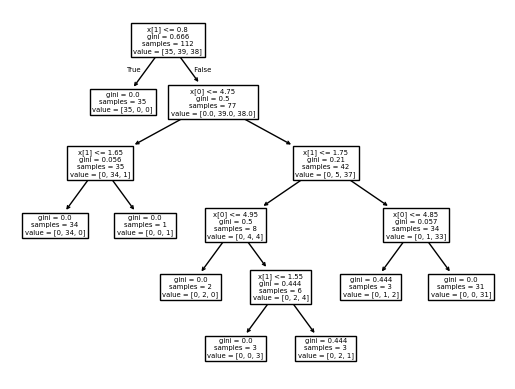

In [6]:
tree.plot_tree(d_tree_model)

In [7]:
# Export graph
tree.export_graphviz(d_tree_model, out_file="iris_tree3.dot",
               feature_names=iris.feature_names[2:],
                #feature_names=iris.feature_names,
               class_names=iris.target_names,
               rounded=True, filled=True)

In [8]:
import os
os.system("dot -Tpng iris_tree3.dot -o iris_tree3.png")

0